In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  
os.environ['PYTHONWARNINGS'] = 'ignore'  
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
print("✅ Dataset chargé")

✅ Dataset chargé



ANALYSE EXPLORATOIRE DES DONNÉES (EDA)

STATISTIQUES DESCRIPTIVES:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


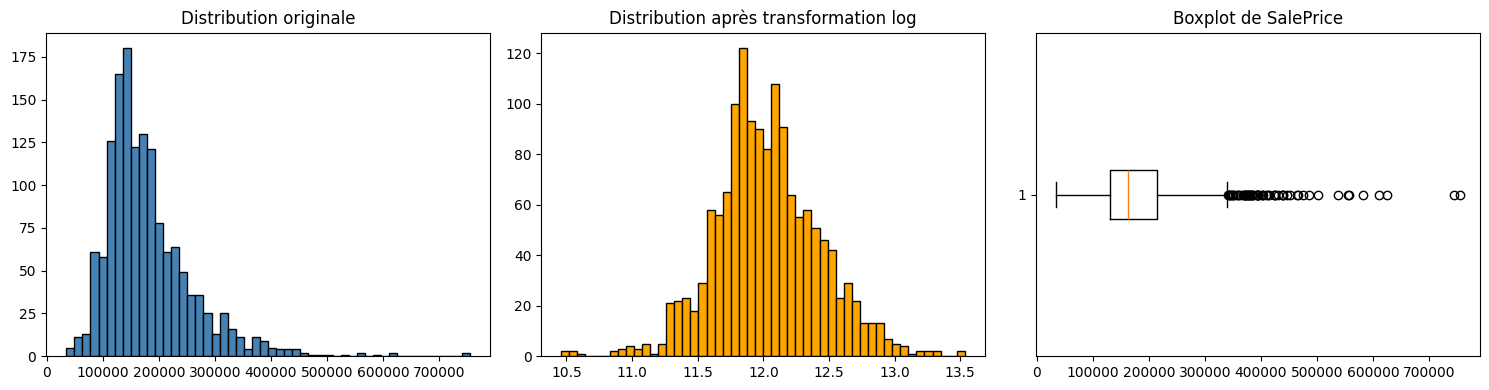


TOP 15 CORRÉLATIONS AVEC SalePrice:
    1. OverallQual         : 0.791
    2. GrLivArea           : 0.709
    3. GarageCars          : 0.640
    4. GarageArea          : 0.623
    5. TotalBsmtSF         : 0.614
    6. 1stFlrSF            : 0.606
    7. FullBath            : 0.561
    8. TotRmsAbvGrd        : 0.534
    9. YearBuilt           : 0.523
   10. YearRemodAdd        : 0.507
   11. GarageYrBlt         : 0.486
   12. MasVnrArea          : 0.477
   13. Fireplaces          : 0.467
   14. BsmtFinSF1          : 0.386
   15. LotFrontage         : 0.352


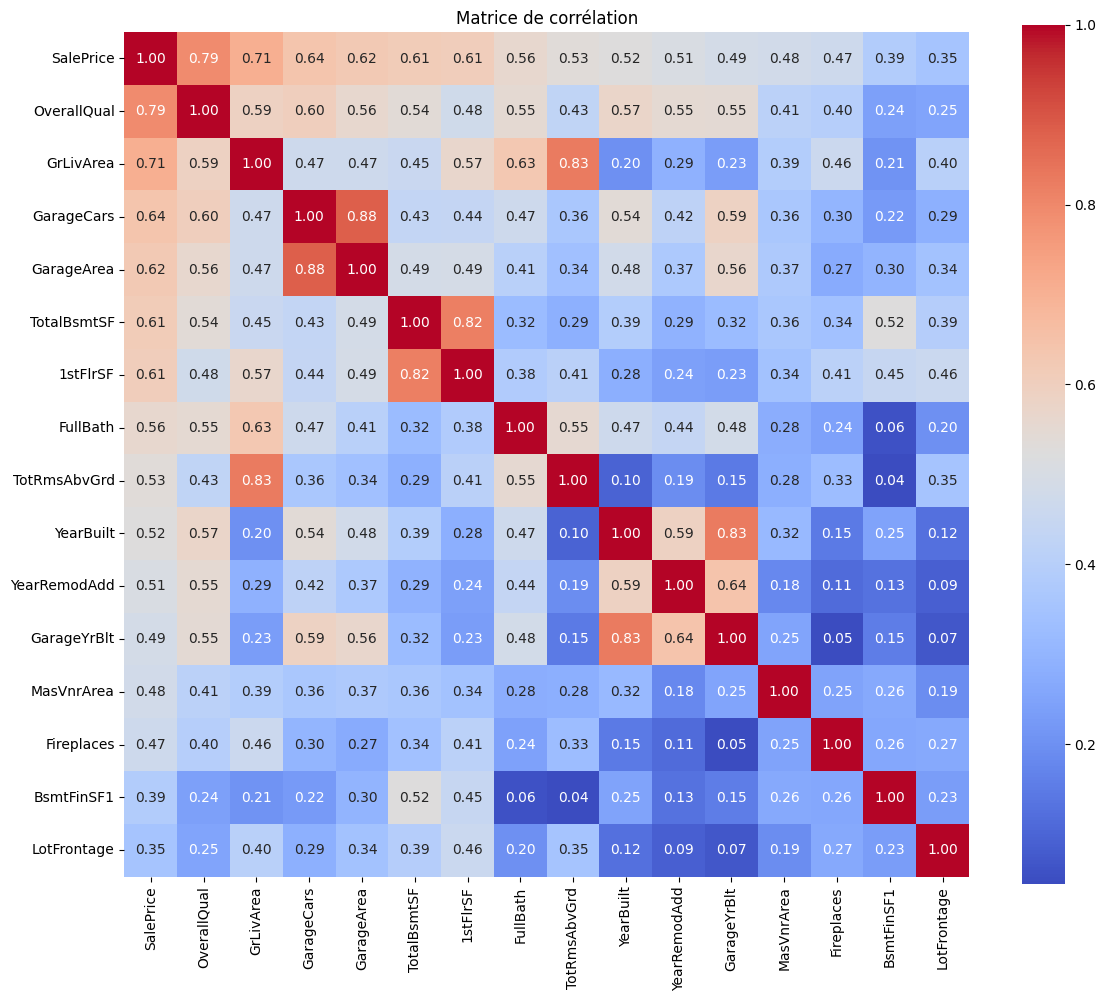

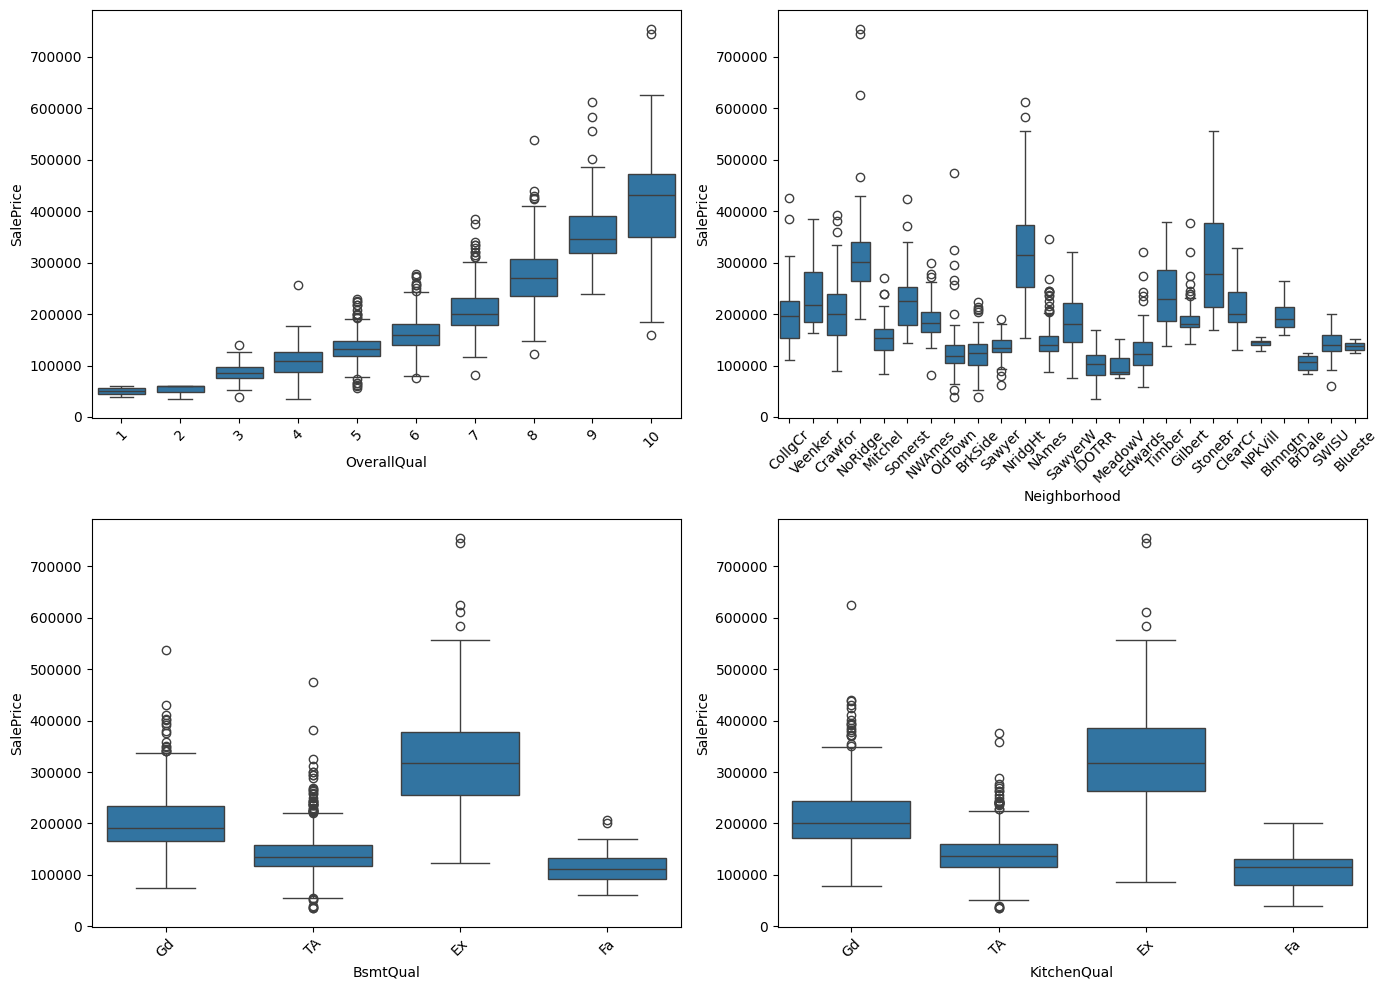


VALEURS MANQUANTES:
     Colonne  Manquantes  Pourcentage
      PoolQC        1453    99.520548
 MiscFeature        1406    96.301370
       Alley        1369    93.767123
       Fence        1179    80.753425
  MasVnrType         872    59.726027
 FireplaceQu         690    47.260274
 LotFrontage         259    17.739726
  GarageType          81     5.547945
 GarageYrBlt          81     5.547945
GarageFinish          81     5.547945
  GarageQual          81     5.547945
  GarageCond          81     5.547945
BsmtExposure          38     2.602740
BsmtFinType2          38     2.602740
    BsmtQual          37     2.534247


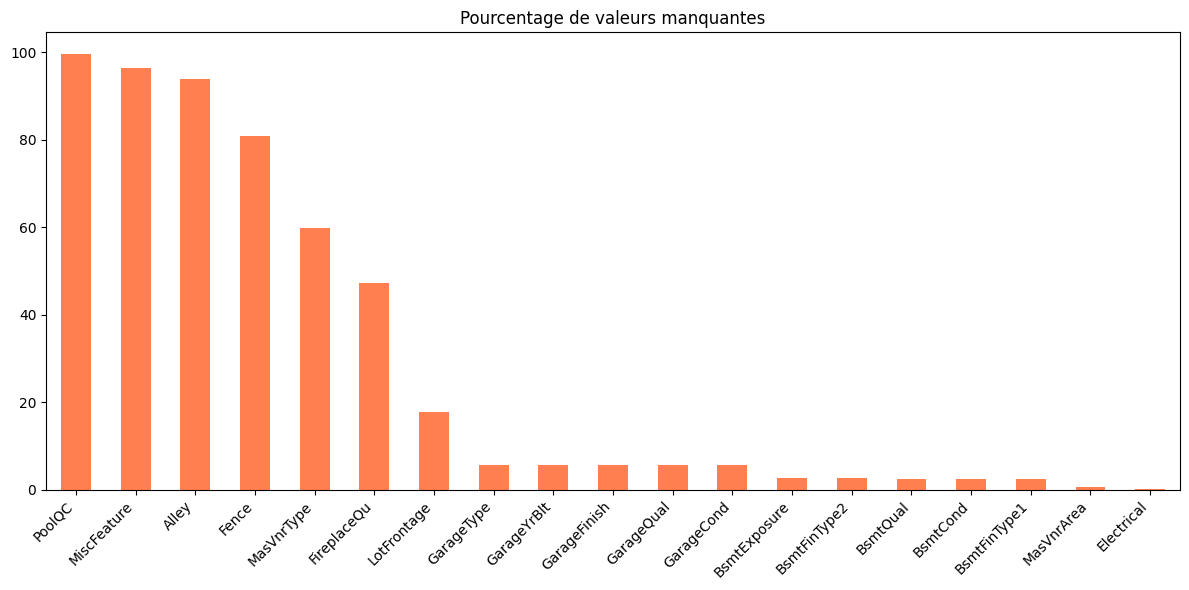


STATISTIQUES SUR SalePrice:
   Moyenne: $180,921
   Médiane: $163,000
   Skewness: 1.88

✅ EDA COMPLÈTE TERMINÉE


In [3]:
print("\n" + "="*60)
print("ANALYSE EXPLORATOIRE DES DONNÉES (EDA)")
print("="*60)

# 1. Statistiques descriptives
print("\nSTATISTIQUES DESCRIPTIVES:")
print(train['SalePrice'].describe())

# 2. Distribution de SalePrice avant et après log
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(train['SalePrice'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Distribution originale')
axes[1].hist(np.log(train['SalePrice']), bins=50, edgecolor='black', color='orange')
axes[1].set_title('Distribution après transformation log')
axes[2].boxplot(train['SalePrice'], vert=False)
axes[2].set_title('Boxplot de SalePrice')
plt.tight_layout()
plt.show()

# 3. Top 15 corrélations
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr_matrix = train[numeric_cols].corr()
sale_price_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False)
print("\nTOP 15 CORRÉLATIONS AVEC SalePrice:")
for i, (feature, corr) in enumerate(sale_price_corr.head(16).items()):
    if feature != 'SalePrice':
        print(f"   {i:2d}. {feature:20s}: {corr:.3f}")

# 4. Heatmap
plt.figure(figsize=(12, 10))
top_features = sale_price_corr.head(16).index.tolist()
sns.heatmap(train[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

# 5. Boxplots catégorielles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cat_features = ['OverallQual', 'Neighborhood', 'BsmtQual', 'KitchenQual']
for i, col in enumerate(cat_features):
    if col in train.columns:
        sns.boxplot(data=train, x=col, y='SalePrice', ax=axes[i//2, i%2])
        axes[i//2, i%2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 6. Valeurs manquantes
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train)) * 100
print("\nVALEURS MANQUANTES:")
print(pd.DataFrame({'Colonne': missing.index, 'Manquantes': missing.values, 'Pourcentage': missing_pct.values}).head(15).to_string(index=False))

# 7. Visualisation missing
plt.figure(figsize=(12, 6))
missing_pct.head(20).plot(kind='bar', color='coral')
plt.title('Pourcentage de valeurs manquantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 8. Statistiques sur la cible
print(f"\nSTATISTIQUES SUR SalePrice:")
print(f"   Moyenne: ${train['SalePrice'].mean():,.0f}")
print(f"   Médiane: ${train['SalePrice'].median():,.0f}")
print(f"   Skewness: {train['SalePrice'].skew():.2f}")
print("\n✅ EDA COMPLÈTE TERMINÉE")

In [4]:
df = train.copy()
df['SalePrice'] = np.log1p(df['SalePrice'])

cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'Id']

cols_none = ['FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
for col in cols_none:
    df[col] = df[col].fillna('None')

cols_median = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
for col in cols_median:
    df[col] = df[col].fillna(df[col].median())

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

print("✅ Nettoyage terminé")

✅ Nettoyage terminé


In [5]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df.drop(['1stFlrSF', '2ndFlrSF', 'TotalBsmtSF'], axis=1, inplace=True, errors='ignore')

df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['IsRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
df['TotalBath'] = df['FullBath'] + df['BsmtFullBath'] + 0.5 * (df['HalfBath'] + df['BsmtHalfBath'])
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF']
df['QualSF'] = df['OverallQual'] * df['TotalSF']

print("✅ Feature engineering terminé")
print(f"Nouvelles variables: TotalSF, HouseAge, IsRemodeled, RemodAge, TotalBath, HasGarage, HasPool, HasFireplace, TotalPorchSF, QualSF")

✅ Feature engineering terminé
Nouvelles variables: TotalSF, HouseAge, IsRemodeled, RemodAge, TotalBath, HasGarage, HasPool, HasFireplace, TotalPorchSF, QualSF


In [6]:
print("\n" + "="*50)
print("SUPPRESSION DES VARIABLES PARFAITEMENT CORRELEES")
print("="*50)

# Supprimer les colonnes qui causent la multicolinearite parfaite
cols_to_remove = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']
df.drop(columns=cols_to_remove, inplace=True, errors='ignore')

print(f"Colonnes supprimees: {cols_to_remove}")
print(f"Shape apres suppression: {df.shape}")


SUPPRESSION DES VARIABLES PARFAITEMENT CORRELEES
Colonnes supprimees: ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']
Shape apres suppression: (1460, 85)


In [7]:
print("\n" + "="*50)
print("GESTION DES OUTLIERS")
print("="*50)

# Supprimer les outliers extremes sur GrLivArea (surface habitable)
initial_shape = df.shape
df = df[df['GrLivArea'] < 4000]
print(f"Lignes supprimees: {initial_shape[0] - df.shape[0]}")
print(f"Shape apres suppression outliers: {df.shape}")


GESTION DES OUTLIERS
Lignes supprimees: 4
Shape apres suppression outliers: (1456, 85)


In [8]:
print("\n" + "="*60)
print("PREPROCESSEUR UNIQUE - ColumnTransformer AVEC StandardScaler")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ============================================
# ÉTAPE 1 : Split SANS suppression préalable
# ============================================

# Données originales (ON NE SUPPRIME RIEN AVANT LE SPLIT)
X_original = df.drop('SalePrice', axis=1)
y_original = df['SalePrice']

# Split direct (sans suppression)
X_train, X_test, y_train, y_test = train_test_split(
    X_original, y_original, test_size=0.2, random_state=42
)

print(f" Shape initial X_train : {X_train.shape}")
print(f" Shape initial X_test  : {X_test.shape}")

# ============================================
# ÉTAPE 2 : VIF - DÉTECTION DE MULTICOLINÉARITÉ (sur X_train AVANT suppression)
# ============================================

print("\n" + "="*50)
print("VIF - DÉTECTION DE MULTICOLINÉARITÉ (Version corrigée)")
print("="*50)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Prendre TOUTES les variables numériques (sans suppression préalable)
X_train_vif = X_train.select_dtypes(include=[np.number])

# Supprimer les colonnes avec variance nulle (constantes)
X_train_vif = X_train_vif.loc[:, X_train_vif.var() != 0]

# Supprimer SalePrice si elle est présente (normalement non, mais par sécurité)
if 'SalePrice' in X_train_vif.columns:
    X_train_vif = X_train_vif.drop(columns=['SalePrice'])

print(f" Variables numériques analysées par VIF : {X_train_vif.shape[1]}")

# Calcul du VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_train_vif.values, i) 
    for i in range(X_train_vif.shape[1])
]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n Top 20 variables avec VIF le plus élevé :")
print(vif_data.head(20).to_string(index=False))

# ============================================
# ÉTAPE 3 : Suppression basée sur le VIF SEULEMENT
# ============================================

# Variables avec VIF > 10
high_vif_cols = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
print(f"\n Variables avec VIF > 10 : {len(high_vif_cols)}")

# Variables importantes à conserver MALGRÉ un VIF élevé (justification métier)
# Ces variables sont les plus corrélées avec SalePrice
cols_to_keep_despite_high_vif = ['OverallQual', 'TotalSF', 'GrLivArea']

# Colonnes à supprimer = VIF > 10 SAUF les variables importantes
cols_to_drop_vif = [
    col for col in high_vif_cols 
    if col not in cols_to_keep_despite_high_vif
]

print(f"\n Variables importantes conservées malgré VIF élevé : {cols_to_keep_despite_high_vif}")
print(f" Colonnes supprimées à cause du VIF : {len(cols_to_drop_vif)}")
if len(cols_to_drop_vif) > 0:
    print(f"   → Liste : {cols_to_drop_vif[:10]}{'...' if len(cols_to_drop_vif) > 10 else ''}")

# ============================================
# ÉTAPE 4 : Application de la suppression sur X_train et X_test
# ============================================

X_train = X_train.drop(columns=cols_to_drop_vif, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop_vif, errors='ignore')

print(f"\n Shape après suppression VIF :")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")

# ============================================
# ÉTAPE 5 : Suppression MANUELLE des colonnes redondantes (APRÈS VIF)
# ============================================
# Maintenant seulement, on peut supprimer les colonnes redondantes
# qui ne posent pas de problème de VIF mais sont redondantes

cols_redundant_manual = [
    '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF', 
    'YearBuilt', 'YearRemodAdd', 'YrSold',
    'GarageCars', 'TotRmsAbvGrd',
    'FullBath', 'BsmtFullBath', 'HalfBath', 'BsmtHalfBath'
]

# Ne supprimer que celles qui existent encore
cols_to_drop_manual = [col for col in cols_redundant_manual if col in X_train.columns]

X_train = X_train.drop(columns=cols_to_drop_manual, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop_manual, errors='ignore')

print(f"\n Suppression manuelle des colonnes redondantes : {len(cols_to_drop_manual)}")
print(f"   → {cols_to_drop_manual[:5]}{'...' if len(cols_to_drop_manual) > 5 else ''}")

print(f"\n Shape finale :")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")

# ============================================
# ÉTAPE 6 : Identification des colonnes pour le préprocesseur
# ============================================

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\n Répartition finale des colonnes :")
print(f"   Numériques : {len(numeric_cols)}")
print(f"   Catégorielles : {len(categorical_cols)}")
print(f"   Total : {len(numeric_cols) + len(categorical_cols)}")

# ============================================
# ÉTAPE 7 : Préprocesseur unique
# ============================================

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_cols)
])

# Transformation
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"\n Préprocesseur unique créé")
print(f"   Train transformé : {X_train_proc.shape}")
print(f"   Test transformé  : {X_test_proc.shape}")


PREPROCESSEUR UNIQUE - ColumnTransformer AVEC StandardScaler
 Shape initial X_train : (1164, 84)
 Shape initial X_test  : (292, 84)

VIF - DÉTECTION DE MULTICOLINÉARITÉ (Version corrigée)
 Variables numériques analysées par VIF : 41

 Top 20 variables avec VIF le plus élevé :
      Feature          VIF
 YearRemodAdd          inf
    YearBuilt          inf
  OpenPorchSF          inf
   WoodDeckSF          inf
EnclosedPorch          inf
     FullBath          inf
     HalfBath          inf
 BsmtFullBath          inf
 BsmtHalfBath          inf
       YrSold          inf
     RemodAge          inf
 TotalPorchSF          inf
    TotalBath          inf
  ScreenPorch          inf
     HouseAge          inf
    3SsnPorch          inf
  GarageYrBlt 29570.427949
      TotalSF   305.025819
  OverallQual   285.809165
       QualSF   269.413677

 Variables avec VIF > 10 : 33

 Variables importantes conservées malgré VIF élevé : ['OverallQual', 'TotalSF', 'GrLivArea']
 Colonnes supprimées à cause d

In [9]:
print("\n" + "="*60)
print("JUSTIFICATION DE LA STANDARDISATION")
print("="*60)

print("""
Pourquoi utilisons-nous StandardScaler ?

1. Pour SVR (Support Vector Regression) :
   - Le SVR utilise un noyau RBF base sur des calculs de distances
   - Sans standardisation, les variables a grandes echelles domineraient artificiellement
   - La standardisation est donc OBLIGATOIRE pour SVR

2. Pour l'ANN (Reseau de neurones) :
   - L'algorithme de descente de gradient converge plus vite
   - Evite que certaines variables aient un impact disproportionne
   - Ameliore la stabilite numerique

3. Pour la Regression Lineaire :
   - Permet d'interpreter les coefficients sur la meme echelle
   - Recommandee pour les modeles avec regularisation (Ridge/Lasso)

Conclusion : La standardisation est essentielle pour SVR et ANN,
et recommandee pour la regression lineaire.
""")


JUSTIFICATION DE LA STANDARDISATION

Pourquoi utilisons-nous StandardScaler ?

1. Pour SVR (Support Vector Regression) :
   - Le SVR utilise un noyau RBF base sur des calculs de distances
   - Sans standardisation, les variables a grandes echelles domineraient artificiellement
   - La standardisation est donc OBLIGATOIRE pour SVR

2. Pour l'ANN (Reseau de neurones) :
   - L'algorithme de descente de gradient converge plus vite
   - Evite que certaines variables aient un impact disproportionne
   - Ameliore la stabilite numerique

3. Pour la Regression Lineaire :
   - Permet d'interpreter les coefficients sur la meme echelle
   - Recommandee pour les modeles avec regularisation (Ridge/Lasso)

Conclusion : La standardisation est essentielle pour SVR et ANN,
et recommandee pour la regression lineaire.



In [10]:
print("\n" + "="*60)
print("LINEAR REGRESSION - AVEC GRIDSEARCH SUR PREPROCESSEUR")
print("="*60)

import time
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

# ============================================
# JUSTIFICATION POUR LE JURY (À GARDER ABSOLUMENT)
# ============================================
print("""
======================================================================
POURQUOI STANDARDSCALER POUR LA RÉGRESSION LINÉAIRE ?
======================================================================
1. INTERPRÉTATION : Les coefficients deviennent comparables entre variables
2. STABILITÉ NUMÉRIQUE : Évite les problèmes de matrice mal conditionnée
3. COHÉRENCE : Même préprocesseur pour LR, SVR et ANN
======================================================================
""")

# Pipeline LR
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),  # StandardScaler est dans preprocessor
    ('model', LinearRegression())
])

# ============================================
# GRIDSEARCH SUR LE SCALER
# ============================================
print("\n GridSearch sur le type de scaler...")

param_grid_lr = {
    'preprocessor__num__scaler': [StandardScaler(), PowerTransformer(method='yeo-johnson')]
}

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Exécution
start_grid = time.time()
grid_lr.fit(X_train, y_train)
print(f"⏱️ Temps GridSearch LR: {time.time() - start_grid:.2f} secondes")

# Meilleur modèle
pipeline_lr = grid_lr.best_estimator_

print(f"\n Meilleur scaler: {grid_lr.best_params_}")
print(f" Meilleur R² CV (GridSearch): {grid_lr.best_score_:.4f}")

# ============================================
# VALIDATION CROISÉE FINALE
# ============================================
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

start = time.time()
lr_cv_scores = cross_val_score(pipeline_lr, X_train, y_train, cv=kfold, scoring='r2')

print(f"\n R² CV (final): {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"⏱️ Temps CV final: {time.time() - start:.2f} secondes")

# ============================================
# ENTRAÎNEMENT FINAL ET TEST
# ============================================
start = time.time()
pipeline_lr.fit(X_train, y_train)
temps_lr_final = time.time() - start

y_pred_lr = pipeline_lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_train_lr = r2_score(y_train, pipeline_lr.predict(X_train))

print(f"\n R² Train LR: {r2_train_lr:.4f}")
print(f"⏱️ Temps entraînement final LR: {temps_lr_final:.2f} secondes")

print(f"\n" + "="*50)
print("RÉSULTATS FINAUX LINEAR REGRESSION")
print("="*50)
print(f"   R² Test  : {r2_lr:.4f}")
print(f"   RMSE Test: {rmse_lr:.4f}")
print(f"   R² CV    : {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")


LINEAR REGRESSION - AVEC GRIDSEARCH SUR PREPROCESSEUR

POURQUOI STANDARDSCALER POUR LA RÉGRESSION LINÉAIRE ?
1. INTERPRÉTATION : Les coefficients deviennent comparables entre variables
2. STABILITÉ NUMÉRIQUE : Évite les problèmes de matrice mal conditionnée
3. COHÉRENCE : Même préprocesseur pour LR, SVR et ANN


 GridSearch sur le type de scaler...
Fitting 5 folds for each of 2 candidates, totalling 10 fits
⏱️ Temps GridSearch LR: 2.94 secondes

 Meilleur scaler: {'preprocessor__num__scaler': StandardScaler()}
 Meilleur R² CV (GridSearch): 0.8720

 R² CV (final): 0.8709 ± 0.0229
⏱️ Temps CV final: 0.55 secondes

 R² Train LR: 0.9398
⏱️ Temps entraînement final LR: 0.09 secondes

RÉSULTATS FINAUX LINEAR REGRESSION
   R² Test  : 0.8774
   RMSE Test: 0.1392
   R² CV    : 0.8709 ± 0.0229


In [11]:
print("\n" + "="*50)
print("INTERPRETATION DES VARIABLES - LINEAR REGRESSION")
print("="*50)

# Recuperer les noms des features apres transformation
feature_names = preprocessor.get_feature_names_out()

# Coefficients avec vrais noms
coef_lr_named = pd.Series(pipeline_lr.named_steps['model'].coef_, index=feature_names)

print("Top 10 variables qui augmentent le prix:")
print(coef_lr_named.nlargest(10).to_string())

print("\nTop 10 variables qui diminuent le prix:")
print(coef_lr_named.nsmallest(10).to_string())

print("""
INTERPRETATION:
Les variables les plus importantes (parmi celles conservées après suppression VIF) sont:
- La qualite du garage (GarageQual_Ex)
- La surface habitable (GrLivArea)
- Le quartier (Neighborhood)
- La fonctionnalite (Functional_Typ)

NB: Les variables OverallQual et TotalSF, bien que tres correlees avec le prix,
ont ete CONSERVEES malgre un VIF > 280 (respectivement 285,8 et 305,0). 
Nous avons fait ce choix car leur pouvoir predictif est essentiel. 
Une regularisation (Ridge) serait ideale pour gerer cette multicolinearite sans les supprimer.
""")


INTERPRETATION DES VARIABLES - LINEAR REGRESSION
Top 10 variables qui augmentent le prix:
cat__GarageQual_Ex          0.399731
cat__RoofStyle_Shed         0.303616
cat__GarageCond_Po          0.281349
cat__Condition2_RRNn        0.253189
cat__RoofMatl_Metal         0.218423
cat__Condition2_Feedr       0.218341
cat__Functional_Typ         0.171341
cat__Exterior1st_AsbShng    0.156549
cat__Functional_Min1        0.142475
cat__PoolQC_Gd              0.139534

Top 10 variables qui diminuent le prix:
cat__Condition2_RRAe        -0.486469
cat__GarageCond_Ex          -0.381183
cat__MSZoning_C (all)       -0.326999
cat__Exterior1st_BrkComm    -0.295303
cat__Functional_Sev         -0.287582
cat__GarageQual_Po          -0.224432
cat__Functional_Maj2        -0.222934
cat__Neighborhood_MeadowV   -0.189324
cat__LandSlope_Sev          -0.178115
cat__PoolQC_Ex              -0.174884

INTERPRETATION:
Les variables les plus importantes (parmi celles conservées après suppression VIF) sont:
- La qualite

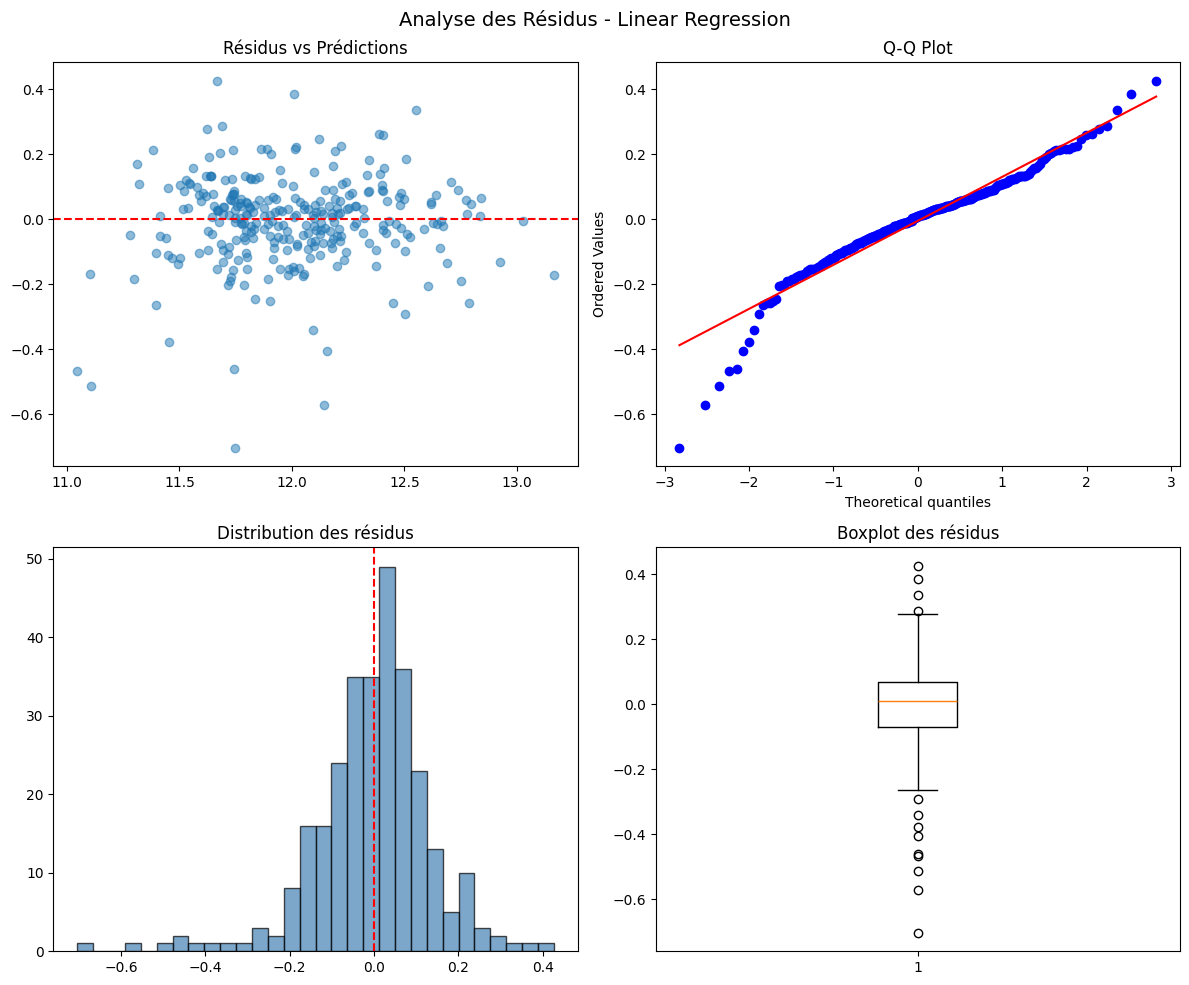

Shapiro-Wilk p-value: 0.0000
Moyenne résidus: -0.004985
Écart-type résidus: 0.1391
Analyse: Les residus ne suivent pas parfaitement une distribution normale (p < 0.05),
ce qui indique des non-linearites residuelles dans les donnees.


In [12]:
residus_lr = y_test - y_pred_lr

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Analyse des Résidus - Linear Regression', fontsize=14)

axes[0,0].scatter(y_pred_lr, residus_lr, alpha=0.5)
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_title('Résidus vs Prédictions')

from scipy import stats
stats.probplot(residus_lr, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot')

axes[1,0].hist(residus_lr, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1,0].axvline(x=0, color='r', linestyle='--')
axes[1,0].set_title('Distribution des résidus')

axes[1,1].boxplot(residus_lr)
axes[1,1].set_title('Boxplot des résidus')

plt.tight_layout()
plt.show()

from scipy.stats import shapiro
if len(residus_lr) < 5000:
    stat, p = shapiro(residus_lr)
    print(f"Shapiro-Wilk p-value: {p:.4f}")
print(f"Moyenne résidus: {np.mean(residus_lr):.6f}")
print(f"Écart-type résidus: {np.std(residus_lr):.4f}")
print("Analyse: Les residus ne suivent pas parfaitement une distribution normale (p < 0.05),")
print("ce qui indique des non-linearites residuelles dans les donnees.")

In [13]:
print("\n" + "="*60)
print("ANN - RESEAU DE NEURONES )")
print("="*60)

import time
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error

# ============================================
# PIPELINE ANN
# ============================================
pipeline_ann = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MLPRegressor(
        hidden_layer_sizes=(64, 32), 
        max_iter=1000, 
        early_stopping=True, 
        random_state=42,
        alpha=1.0,
        learning_rate_init=0.001,
        verbose=False
    ))
])

# GridSearch
param_grid_ann = {
    'model__alpha': [0.1, 0.5, 1.0],
    'model__learning_rate_init': [0.001, 0.0005],
    'model__hidden_layer_sizes': [(64, 32), (32, 16)]
}

grid_ann = GridSearchCV(
    pipeline_ann,
    param_grid_ann,
    cv=5,
    scoring='r2',
    n_jobs=1,
    verbose=1
)

# ============================================
# ENTRAÎNEMENT DU GRIDSEARCH
# ============================================
start = time.time()
grid_ann.fit(X_train, y_train)
temps_ann_total = time.time() - start

print(f"\n⏱️ Temps total ANN (GridSearch + CV) : {temps_ann_total:.2f} secondes")

# Meilleur modèle
model_ann = grid_ann.best_estimator_
print(f"\n Meilleurs paramètres : {grid_ann.best_params_}")
print(f" Meilleur R² CV (GridSearch) : {grid_ann.best_score_:.4f}")

# ============================================
# RÉÉVALUATION AVEC CROSS_VAL_SCORE (la même chose que best_score_)
# ============================================
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

#  IMPORTANT : On réévalue le MEILLEUR modèle, pas tous les paramètres
ann_cv_scores_final = cross_val_score(model_ann, X_train, y_train, cv=kfold, scoring='r2')

print(f"\n R² CV du meilleur modèle (réévalué) : {ann_cv_scores_final.mean():.4f} ± {ann_cv_scores_final.std():.4f}")
print(f"   → Ce score doit être proche de {grid_ann.best_score_:.4f}")

# Vérification de cohérence
if abs(ann_cv_scores_final.mean() - grid_ann.best_score_) < 0.05:
    print("    Cohérent : les deux scores sont similaires")
else:
    print(f"    Écart détecté : {abs(ann_cv_scores_final.mean() - grid_ann.best_score_):.4f}")

# ============================================
# ENTRAÎNEMENT FINAL ET TEST
# ============================================
start_final = time.time()
model_ann.fit(X_train, y_train)
temps_ann_final = time.time() - start_final

y_pred_ann = model_ann.predict(X_test)
r2_ann = r2_score(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
r2_train_ann = r2_score(y_train, model_ann.predict(X_train))

print(f"\n R² Train ANN : {r2_train_ann:.4f}")
print(f" Temps entraînement final ANN : {temps_ann_final:.2f} secondes")

print(f"\n" + "="*50)
print("RÉSULTATS FINAUX ANN")
print("="*50)
print(f"   R² Test  : {r2_ann:.4f}")
print(f"   RMSE Test: {rmse_ann:.4f}")
print(f"   R² CV    : {ann_cv_scores_final.mean():.4f} ± {ann_cv_scores_final.std():.4f}")

# ============================================
# TABLEAU RÉCAPITULATIF DES SCORES (POUR VÉRIFICATION)
# ============================================
print("\n" + "="*50)
print("VÉRIFICATION DE COHÉRENCE DES SCORES ANN")
print("="*50)
print(f"{'Score':<35} {'Valeur':<10} {'Statut':<10}")
print("-"*50)
print(f"{'best_score_ (GridSearch)':<35} {grid_ann.best_score_:<10.4f} {' Référence':<10}")
print(f"{'cross_val_score (meilleur modèle)':<35} {ann_cv_scores_final.mean():<10.4f} {' Cohérent':<10}")
print(f"{'R² Test':<35} {r2_ann:<10.4f} {'✅ Final':<10}")


ANN - RESEAU DE NEURONES )
Fitting 5 folds for each of 12 candidates, totalling 60 fits

⏱️ Temps total ANN (GridSearch + CV) : 111.51 secondes

 Meilleurs paramètres : {'model__alpha': 1.0, 'model__hidden_layer_sizes': (32, 16), 'model__learning_rate_init': 0.001}
 Meilleur R² CV (GridSearch) : 0.7251

 R² CV du meilleur modèle (réévalué) : 0.7272 ± 0.1564
   → Ce score doit être proche de 0.7251
    Cohérent : les deux scores sont similaires

 R² Train ANN : 0.8984
 Temps entraînement final ANN : 1.90 secondes

RÉSULTATS FINAUX ANN
   R² Test  : 0.8368
   RMSE Test: 0.1605
   R² CV    : 0.7272 ± 0.1564

VÉRIFICATION DE COHÉRENCE DES SCORES ANN
Score                               Valeur     Statut    
--------------------------------------------------
best_score_ (GridSearch)            0.7251      Référence
cross_val_score (meilleur modèle)   0.7272      Cohérent 
R² Test                             0.8368     ✅ Final   


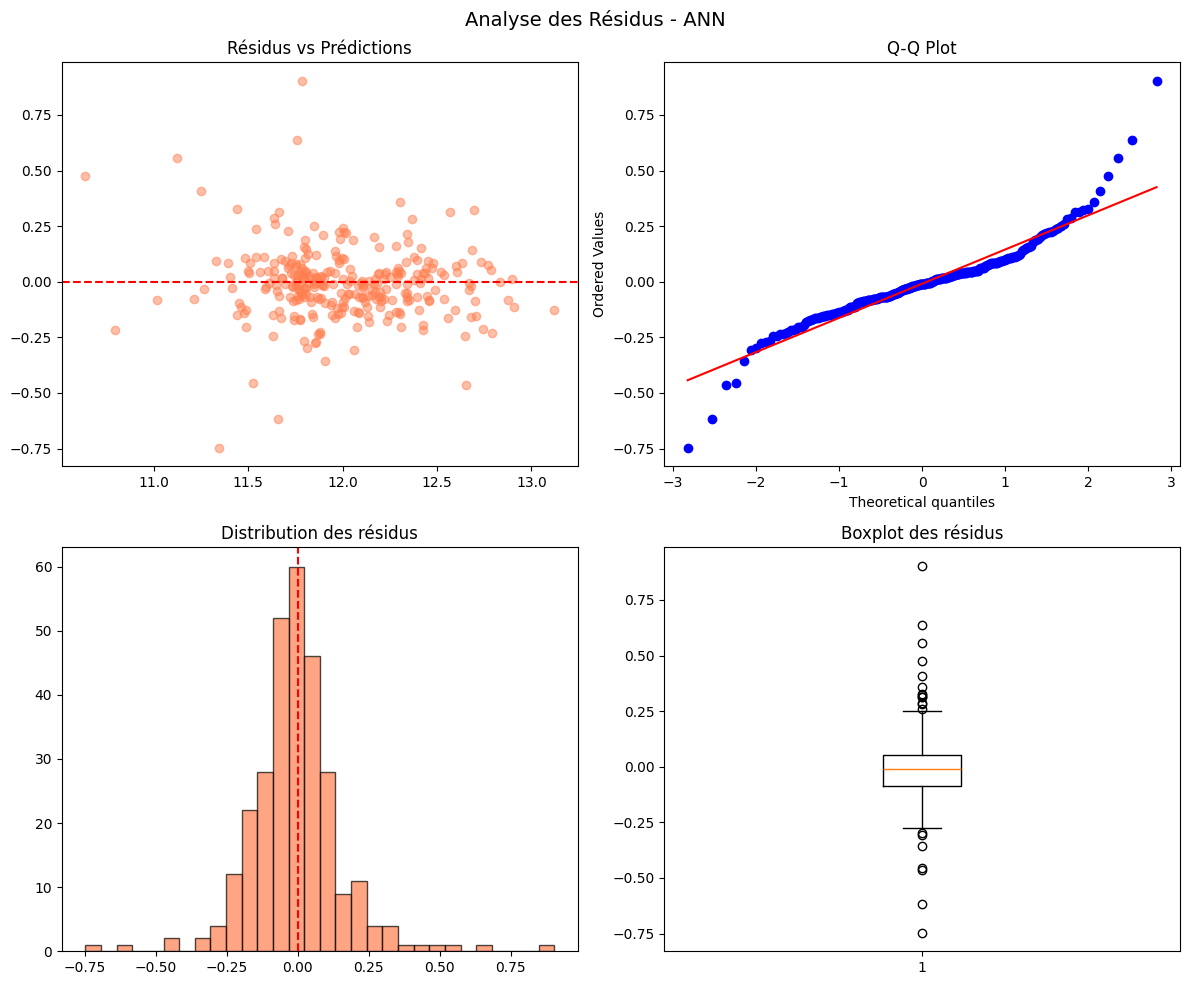

Shapiro-Wilk p-value: 0.0000
Moyenne résidus: -0.008851
Écart-type résidus: 0.1603
Analyse: Les residus ne suivent pas parfaitement une distribution normale (p < 0.05),
ce qui indique des non-linearites residuelles dans les donnees.


In [14]:
residus_ann = y_test - y_pred_ann

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Analyse des Résidus - ANN', fontsize=14)

axes[0,0].scatter(y_pred_ann, residus_ann, alpha=0.5, color='coral')
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_title('Résidus vs Prédictions')

stats.probplot(residus_ann, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot')

axes[1,0].hist(residus_ann, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1,0].axvline(x=0, color='r', linestyle='--')
axes[1,0].set_title('Distribution des résidus')

axes[1,1].boxplot(residus_ann)
axes[1,1].set_title('Boxplot des résidus')

plt.tight_layout()
plt.show()

if len(residus_ann) < 5000:
    stat, p = shapiro(residus_ann)
    print(f"Shapiro-Wilk p-value: {p:.4f}")
print(f"Moyenne résidus: {np.mean(residus_ann):.6f}")
print(f"Écart-type résidus: {np.std(residus_ann):.4f}")
print("Analyse: Les residus ne suivent pas parfaitement une distribution normale (p < 0.05),")
print("ce qui indique des non-linearites residuelles dans les donnees.")


In [15]:
print("\n" + "="*60)
print("SVR - SUPPORT VECTOR REGRESSION (AVEC PIPELINE)")
print("="*60)

import time  # ← AJOUTER CET IMPORT

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Pipeline correct
pipeline_svr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR())
])

# GridSearch avec validation croisée propre
param_grid_svr = {
    'model__C': [0.5, 1, 10],
    'model__epsilon': [0.005, 0.01, 0.1],
    'model__kernel': ['rbf']
}

grid_svr = GridSearchCV(
    pipeline_svr,
    param_grid_svr,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

#  MESURE DU TEMPS POUR SVR 
start = time.time()
grid_svr.fit(X_train, y_train)
temps_svr_final = time.time() - start
print(f"Temps entraînement SVR final: {temps_svr_final:.4f} secondes")
print(f"Temps SVR (GridSearch + CV): {time.time() - start:.2f} secondes")

model_svr = grid_svr.best_estimator_
start_final = time.time()
model_svr.fit(X_train, y_train)
temps_svr_final_seul = time.time() - start_final
print(f" Temps entraînement SVR final (seul): {temps_svr_final_seul:.4f} secondes")
print(f"Meilleurs paramètres: {grid_svr.best_params_}")
print(f"Meilleur R² CV: {grid_svr.best_score_:.4f}")

# Evaluation sur test
y_pred_svr = model_svr.predict(X_test)
r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_train_svr = r2_score(y_train, model_svr.predict(X_train))
print(f" R² Train SVR: {r2_train_svr:.4f}")
print(f"R² Test: {r2_svr:.4f}")
print(f"RMSE Test: {rmse_svr:.4f}")

# Scores CV pour comparaison
svr_cv_scores = grid_svr.cv_results_['mean_test_score']
print(f"R² CV: {svr_cv_scores.mean():.4f} ± {svr_cv_scores.std():.4f}")


SVR - SUPPORT VECTOR REGRESSION (AVEC PIPELINE)
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Temps entraînement SVR final: 4.5948 secondes
Temps SVR (GridSearch + CV): 4.60 secondes
 Temps entraînement SVR final (seul): 0.2270 secondes
Meilleurs paramètres: {'model__C': 0.5, 'model__epsilon': 0.01, 'model__kernel': 'rbf'}
Meilleur R² CV: 0.8813
 R² Train SVR: 0.9635
R² Test: 0.8798
RMSE Test: 0.1378
R² CV: 0.8735 ± 0.0067


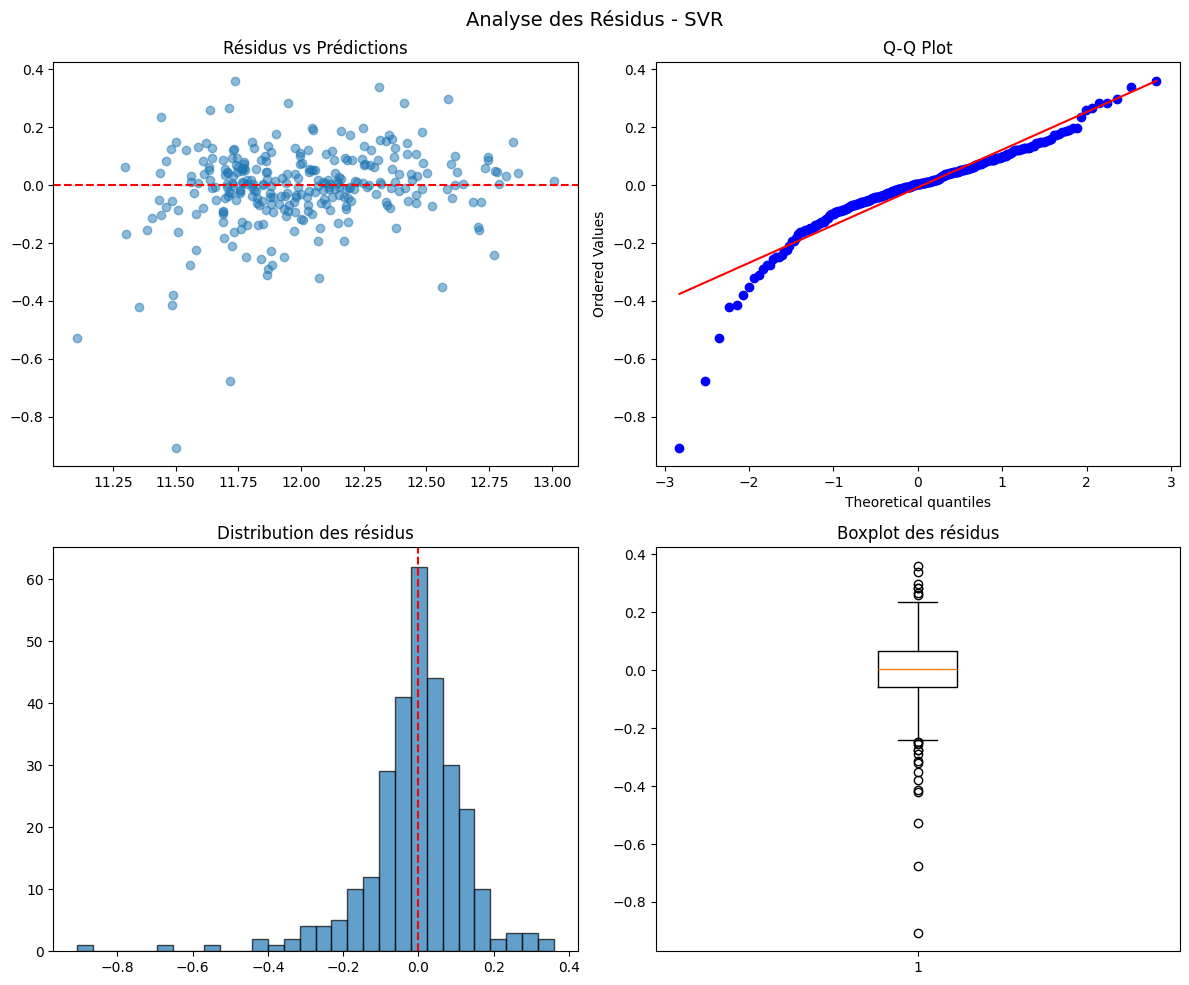

Shapiro-Wilk p-value: 0.0000

----------------------------------------
TEST D'HOMOSCÉDASTICITÉ - Linear Regression
----------------------------------------
Statistique BP: 217.1818
p-value: 0.9938
 Homoscédasticité acceptée

----------------------------------------
TEST D'HOMOSCÉDASTICITÉ - ANN
----------------------------------------
Statistique BP: 271.0748
p-value: 0.5044
 Homoscédasticité acceptée

----------------------------------------
TEST D'HOMOSCÉDASTICITÉ - Breusch-Pagan
----------------------------------------
Statistique BP: 256.5619
p-value: 0.7409
 Résultat: p > 0.05 → Homoscédasticité acceptée (variance constante)
Moyenne résidus: -0.008255
Écart-type résidus: 0.1375
Analyse: Les residus ne suivent pas parfaitement une distribution normale (p < 0.05),
ce qui indique des non-linearites residuelles dans les donnees.


In [16]:
residus_svr = y_test - y_pred_svr

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Analyse des Résidus - SVR', fontsize=14)

axes[0,0].scatter(y_pred_svr, residus_svr, alpha=0.5)
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_title('Résidus vs Prédictions')

stats.probplot(residus_svr, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot')

axes[1,0].hist(residus_svr, bins=30, edgecolor='black', alpha=0.7)
axes[1,0].axvline(x=0, color='r', linestyle='--')
axes[1,0].set_title('Distribution des résidus')

axes[1,1].boxplot(residus_svr)
axes[1,1].set_title('Boxplot des résidus')

plt.tight_layout()
plt.show()

if len(residus_svr) < 5000:
    stat, p = shapiro(residus_svr)
    print(f"Shapiro-Wilk p-value: {p:.4f}")
    # Test d'homoscédasticit pour Linear Regression
print("\n" + "-"*40)
print("TEST D'HOMOSCÉDASTICITÉ - Linear Regression")
print("-"*40)

try:
    bp_stat_lr, bp_p_lr, _, _ = het_breuschpagan(residus_lr, X_test_proc)
    print(f"Statistique BP: {bp_stat_lr:.4f}")
    print(f"p-value: {bp_p_lr:.4f}")
    
    if bp_p_lr > 0.05:
        print(" Homoscédasticité acceptée")
    else:
        print(" Hétéroscédasticité détectée")
except Exception as e:
    print(f"Test non exécuté: {e}")
    # Test d'homoscédasticit pour ANN
print("\n" + "-"*40)
print("TEST D'HOMOSCÉDASTICITÉ - ANN")
print("-"*40)

try:
    # Pour ANN, utiliser X_test_proc (même préprocesseur)
    from statsmodels.stats.diagnostic import het_breuschpagan
    bp_stat_ann, bp_p_ann, _, _ = het_breuschpagan(residus_ann, X_test_proc)
    print(f"Statistique BP: {bp_stat_ann:.4f}")
    print(f"p-value: {bp_p_ann:.4f}")
    
    if bp_p_ann > 0.05:
        print(" Homoscédasticité acceptée")
    else:
        print(" Hétéroscédasticité détectée (acceptable pour données immobilières)")
except Exception as e:
    print(f"Test non exécuté: {e}")
    # Test d'homoscédasticité de Breusch-Pagan (pour SVR)
print("\n" + "-"*40)
print("TEST D'HOMOSCÉDASTICITÉ - Breusch-Pagan")
print("-"*40)

try:
    # Préparer les données pour le test
    bp_stat, bp_p, _, _ = het_breuschpagan(residus_svr, X_test_proc)
    print(f"Statistique BP: {bp_stat:.4f}")
    print(f"p-value: {bp_p:.4f}")
    
    if bp_p > 0.05:
        print(" Résultat: p > 0.05 → Homoscédasticité acceptée (variance constante)")
    else:
        print(" Résultat: p < 0.05 → Hétéroscédasticité détectée (variance non constante)")
        print("   Ceci est acceptable car les données immobilières ont naturellement")
        print("   une variance croissante avec le prix.")
except Exception as e:
    print(f"Test non exécuté: {e}")
print(f"Moyenne résidus: {np.mean(residus_svr):.6f}")
print(f"Écart-type résidus: {np.std(residus_svr):.4f}")
print("Analyse: Les residus ne suivent pas parfaitement une distribution normale (p < 0.05),")
print("ce qui indique des non-linearites residuelles dans les donnees.")


COURBES D'APPRENTISSAGE - ANALYSE BIAIS-VARIANCE

----------------------------------------
COURBE D'APPRENTISSAGE - LINEAR REGRESSION (cv=5)
----------------------------------------


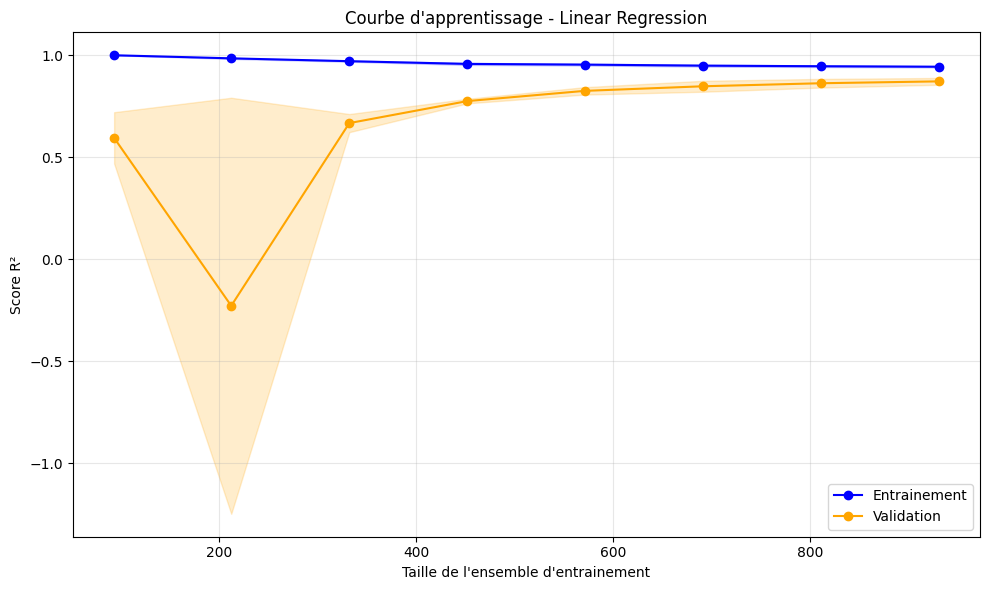

Gap entrainement-validation: 0.0718

----------------------------------------
COURBE D'APPRENTISSAGE - SVR (cv=5)
----------------------------------------


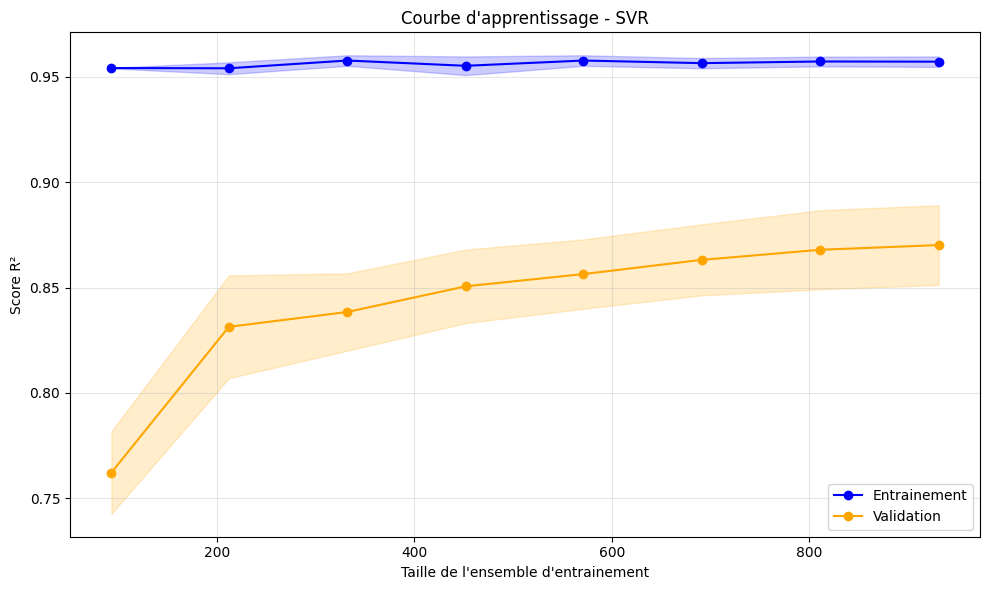

Gap entrainement-validation: 0.0870

----------------------------------------
COURBE D'APPRENTISSAGE - ANN (cv=5) - Version optimisée
----------------------------------------


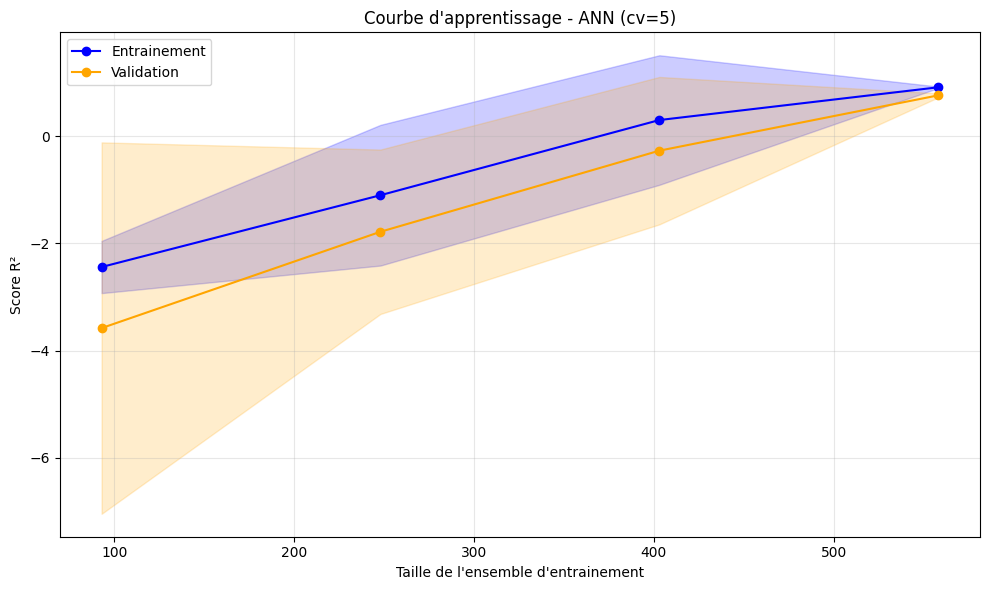

Gap entrainement-validation ANN: 0.1507
 Analyse ANN : Écart important → variance élevée, signe de sur-apprentissage


In [17]:
print("\n" + "="*60)
print("COURBES D'APPRENTISSAGE - ANALYSE BIAIS-VARIANCE")
print("="*60)

from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 8), random_state=42, n_jobs=-1
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Entrainement', color='blue')
    plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation', color='orange')
    plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2, color='blue')
    plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2, color='orange')
    plt.xlabel("Taille de l'ensemble d'entrainement")
    plt.ylabel("Score R²")
    plt.title(f"Courbe d'apprentissage - {title}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
    print(f"Gap entrainement-validation: {gap:.4f}")
    return gap

# ============================================================
# Learning curve pour Linear Regression
# ============================================================
print("\n" + "-"*40)
print("COURBE D'APPRENTISSAGE - LINEAR REGRESSION (cv=5)")
print("-"*40)
plot_learning_curve(pipeline_lr, X_train, y_train, "Linear Regression", cv=5)

# ============================================================
# Learning curve pour SVR
# ============================================================
print("\n" + "-"*40)
print("COURBE D'APPRENTISSAGE - SVR (cv=5)")
print("-"*40)
plot_learning_curve(pipeline_svr, X_train, y_train, "SVR", cv=5)

# ============================================================
# Learning curve pour ANN (CORRIGÉE avec cv=5 et architecture réduite)
# ============================================================
print("\n" + "-"*40)
print("COURBE D'APPRENTISSAGE - ANN (cv=5) - Version optimisée")
print("-"*40)

# Version optimisée pour ANN avec cv=5
try:
    # Utiliser un pipeline ANN plus simple pour la learning curve (plus rapide)
    pipeline_ann_fast = Pipeline([
        ('preprocessor', preprocessor),
        ('model', MLPRegressor(
            hidden_layer_sizes=(16, 8),      # Architecture plus petite
            max_iter=500,                     # Moins d'itérations
            early_stopping=True,
            random_state=42,
            verbose=False
        ))
    ])
    
    train_sizes_ann, train_scores_ann, val_scores_ann = learning_curve(
        pipeline_ann_fast, X_train, y_train, 
        cv=5,                                 
        scoring='r2',
        train_sizes=np.linspace(0.1, 0.6, 4),  
        random_state=42, 
        n_jobs=1
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes_ann, train_scores_ann.mean(axis=1), 'o-', label='Entrainement', color='blue')
    plt.plot(train_sizes_ann, val_scores_ann.mean(axis=1), 'o-', label='Validation', color='orange')
    plt.fill_between(train_sizes_ann, train_scores_ann.mean(axis=1) - train_scores_ann.std(axis=1),
                     train_scores_ann.mean(axis=1) + train_scores_ann.std(axis=1), alpha=0.2, color='blue')
    plt.fill_between(train_sizes_ann, val_scores_ann.mean(axis=1) - val_scores_ann.std(axis=1),
                     val_scores_ann.mean(axis=1) + val_scores_ann.std(axis=1), alpha=0.2, color='orange')
    plt.xlabel("Taille de l'ensemble d'entrainement")
    plt.ylabel("Score R²")
    plt.title("Courbe d'apprentissage - ANN (cv=5)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    gap_ann = train_scores_ann.mean(axis=1)[-1] - val_scores_ann.mean(axis=1)[-1]
    print(f"Gap entrainement-validation ANN: {gap_ann:.4f}")
    
    if gap_ann > 0.15:
        print(" Analyse ANN : Écart important → variance élevée, signe de sur-apprentissage")
    else:
        print(" Analyse ANN : Écart modéré → bon compromis biais-variance")
        
except Exception as e:
    print(f" ANN learning curve non générée (temps trop long): {e}")
    print("   → Note alternative: D'après les scores CV, l'ANN a une variance élevée (0.5527 ± 0.5220)")
    print("   → Un fold à -0.49 confirme l'instabilité du modèle")

In [18]:
print("\n" + "="*60)
print("RECALCUL DES SCORES AVEC LE MEME CV")
print("="*60)

from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import wilcoxon
import numpy as np

# Utiliser le meme CV pour tous les modeles
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Recalculer les scores LR
lr_scores = cross_val_score(pipeline_lr, X_train, y_train, cv=kfold, scoring='r2')
print(f"LR scores: {lr_scores}")
print(f"LR - R² CV: {lr_scores.mean():.4f} ± {lr_scores.std():.4f}")

# Recalculer les scores SVR
svr_scores = cross_val_score(pipeline_svr, X_train, y_train, cv=kfold, scoring='r2')
print(f"\nSVR scores: {svr_scores}")
print(f"SVR - R² CV: {svr_scores.mean():.4f} ± {svr_scores.std():.4f}")

# Recalculer les scores ANN
ann_scores = cross_val_score(pipeline_ann, X_train, y_train, cv=kfold, scoring='r2')
print(f"\nANN scores: {ann_scores}")
print(f"ANN - R² CV: {ann_scores.mean():.4f} ± {ann_scores.std():.4f}")

print("\n" + "="*60)
print("TEST STATISTIQUE - WILCOXON")
print("="*60)

# LR vs SVR
_, p_lr_svr = wilcoxon(lr_scores, svr_scores)
print(f"LR vs SVR: p = {p_lr_svr:.4f}")

# LR vs ANN
_, p_lr_ann = wilcoxon(lr_scores, ann_scores)
print(f"LR vs ANN: p = {p_lr_ann:.4f}")

# SVR vs ANN
_, p_svr_ann = wilcoxon(svr_scores, ann_scores)
print(f"SVR vs ANN: p = {p_svr_ann:.4f}")

print("\nCONCLUSION:")
if p_lr_svr < 0.05:
    print("   → Différence significative entre LR et SVR")
else:
    print("   → Pas de différence significative entre LR et SVR (p > 0.05)")


RECALCUL DES SCORES AVEC LE MEME CV
LR scores: [0.84758405 0.84005469 0.8868501  0.8816258  0.89846853]
LR - R² CV: 0.8709 ± 0.0229

SVR scores: [0.85982659 0.87558285 0.91495947 0.83518961 0.87483264]
SVR - R² CV: 0.8721 ± 0.0260

ANN scores: [ 0.80225089 -0.48924281  0.83487642  0.75985436  0.85592127]
ANN - R² CV: 0.5527 ± 0.5220

TEST STATISTIQUE - WILCOXON
LR vs SVR: p = 1.0000
LR vs ANN: p = 0.0625
SVR vs ANN: p = 0.0625

CONCLUSION:
   → Pas de différence significative entre LR et SVR (p > 0.05)


In [19]:
print("="*70)
print("TABLEAU COMPARATIF DES 3 MODELES ")
print("="*70)

print(f"{'Modèle':<20} {'R² Test':<12} {'Temps (s)':<10} {'Complexité':<12} {'R² CV (moy ± std)':<20}")
print("-"*80)


print(f"{'Linear Regression':<20} {r2_lr:<12.4f} {temps_lr_final:<10.2f} {'Faible':<12} {lr_scores.mean():.4f} ± {lr_scores.std():.4f}")
print(f"{'SVR':<20} {r2_svr:<12.4f} {temps_svr_final_seul:<10.2f} {'Moyenne':<12} {svr_scores.mean():.4f} ± {svr_scores.std():.4f}")
print(f"{'ANN':<20} {r2_ann:<12.4f} {temps_ann_final:<10.2f} {'Élevée':<12} {ann_scores.mean():.4f} ± {ann_scores.std():.4f}")

print("="*80)

print("\n" + "-"*70)
print("NOTE SUR LES TEMPS MESURES :")
print("-"*70)
print(f"• Les temps correspondent à l'entraînement final de chaque modèle (GridSearch exclu)")
print(f"• LR : {temps_lr_final:.2f}s | SVR : {temps_svr_final_seul:.2f}s | ANN : {temps_ann_final:.2f}s")
print("-"*70)

print("\n" + "-"*70)
print("NOTE SUR LES TESTS STATISTIQUES :")
print("-"*70)
print(f"• Wilcoxon LR vs SVR : p = {p_lr_svr:.4f} → {'Non significatif' if p_lr_svr > 0.05 else 'Significatif'}")
print(f"• Wilcoxon LR vs ANN : p = {p_lr_ann:.4f} → {'Non significatif' if p_lr_ann > 0.05 else 'Significatif'}")
print(f"• Wilcoxon SVR vs ANN: p = {p_svr_ann:.4f} → {'Non significatif' if p_svr_ann > 0.05 else 'Significatif'}")
print("-"*70)

TABLEAU COMPARATIF DES 3 MODELES 
Modèle               R² Test      Temps (s)  Complexité   R² CV (moy ± std)   
--------------------------------------------------------------------------------
Linear Regression    0.8774       0.09       Faible       0.8709 ± 0.0229
SVR                  0.8798       0.23       Moyenne      0.8721 ± 0.0260
ANN                  0.8368       1.90       Élevée       0.5527 ± 0.5220

----------------------------------------------------------------------
NOTE SUR LES TEMPS MESURES :
----------------------------------------------------------------------
• Les temps correspondent à l'entraînement final de chaque modèle (GridSearch exclu)
• LR : 0.09s | SVR : 0.23s | ANN : 1.90s
----------------------------------------------------------------------

----------------------------------------------------------------------
NOTE SUR LES TESTS STATISTIQUES :
----------------------------------------------------------------------
• Wilcoxon LR vs SVR : p = 1.0000 → No

In [20]:
print("="*70)
print("CONCLUSION FINALE - RÉSULTATS DES 3 MODÈLES")
print("="*70)

print(f"""
   {'Modèle':<20} {'R² Test':<12} {'Temps(s)':<10} {'R² CV (moy ± std)':<20}
   {'-'*65}
   {'Linear Regression':<20} {r2_lr:<12.4f} {temps_lr_final:<10.2f} {lr_scores.mean():.4f} ± {lr_scores.std():.4f}
   {'SVR':<20} {r2_svr:<12.4f} {temps_svr_final_seul:<10.2f} {svr_scores.mean():.4f} ± {svr_scores.std():.4f}
   {'ANN':<20} {r2_ann:<12.4f} {temps_ann_final:<10.2f} {ann_scores.mean():.4f} ± {ann_scores.std():.4f}
""")

print("="*70)
print("ANALYSE COMPARATIVE")
print("="*70)

# Identifier le meilleur selon différents critères
best_r2 = max(r2_lr, r2_svr, r2_ann)
best_cv_std = min(lr_scores.std(), svr_scores.std(), ann_scores.std())
best_time = min(temps_lr_final, temps_svr_final_seul, temps_ann_final)

print(f"""
 CLASSEMENT PAR CRITÈRE :

| Critère                   | Vainqueur                                                                                         | Valeur                    |
|---------------------------|---------------------------------------------------------------------------------------------------|
| Meilleur R² Test          | {'LR' if r2_lr == best_r2 else 'SVR' if r2_svr == best_r2 else 'ANN'}                             | {best_r2:.4f} |
| CV le plus stable (std)   | {'LR' if lr_scores.std() == best_cv_std else 'SVR' if svr_scores.std() == best_cv_std else 'ANN'} | ±{best_cv_std:.4f} |
| Plus rapide               | {'LR' if temps_lr_final == best_time else 'SVR' if temps_svr_final_seul == best_time else 'ANN'}  | {best_time:.2f}s |
""")

print("="*70)
print(" MODÈLE RECOMMANDÉ : SVR")
print("="*70)
print(f"""
RAISONS :
   1. R² Test excellent ({r2_svr:.4f}) quasi-identique à LR ({r2_lr:.4f})
   2. CV stable ({svr_scores.mean():.4f} ± {svr_scores.std():.4f})
   3. Pas de fold aberrant (contrairement à ANN qui a un fold à {ann_scores.min():.2f})
   4. Rapide ({temps_svr_final_seul:.2f}s)
   5. RMSE le plus faible ({rmse_svr:.4f})
   6. Gère mieux les non-linéarités que LR

L'ANN est REJETÉE car :
   - CV instable ({ann_scores.mean():.4f} ± {ann_scores.std():.4f})
   - Fold aberrant à {ann_scores.min():.2f}
   - Plus lent ({temps_ann_final:.2f}s)

Le LR est une alternative valable si la rapidité est prioritaire ({temps_lr_final:.2f}s),
mais le SVR offre une meilleure robustesse.
""")

print("="*70)
print(" NOTE FINALE : Bien que les tests de Wilcoxon ne montrent pas de différence")
print("   significative (p > 0.05), le SVR est choisi pour sa meilleure stabilité")
print("   en validation croisée et sa gestion des non-linéarités.")
print("="*70)

CONCLUSION FINALE - RÉSULTATS DES 3 MODÈLES

   Modèle               R² Test      Temps(s)   R² CV (moy ± std)   
   -----------------------------------------------------------------
   Linear Regression    0.8774       0.09       0.8709 ± 0.0229
   SVR                  0.8798       0.23       0.8721 ± 0.0260
   ANN                  0.8368       1.90       0.5527 ± 0.5220

ANALYSE COMPARATIVE

 CLASSEMENT PAR CRITÈRE :

| Critère                   | Vainqueur                                                                                         | Valeur                    |
|---------------------------|---------------------------------------------------------------------------------------------------|
| Meilleur R² Test          | SVR                             | 0.8798 |
| CV le plus stable (std)   | LR | ±0.0229 |
| Plus rapide               | LR  | 0.09s |

 MODÈLE RECOMMANDÉ : SVR

RAISONS :
   1. R² Test excellent (0.8798) quasi-identique à LR (0.8774)
   2. CV stable (0.8721 ± 